In [36]:
# from unqomp.examples.adder import makesAdder, makesMult, makesCirqAdder, makesCirqMult
from qiskit.visualization import circuit_drawer, dag_drawer
# import qiskit

In [37]:
# built from https://github.com/quantumlib/Cirq/blob/master/examples/basic_arithmetic.py
from qiskit.circuit import QuantumRegister, QuantumCircuit

from unqomp.ancillaallocation import AncillaRegister, AncillaCircuit

def makesAdder(num_qubits):
    #[a, b]: b = a + b, a and b made of num_qubits each
    # returns an AncillaCircuit, without uncomputation
    def neg_mct_gate():
        neg_mct = AncillaCircuit(4)
        neg_mct.cx(1, 2)
        neg_mct.ccx(0, 2, 3)
        neg_mct.cx(1, 2)
        return neg_mct.to_ancilla_gate(True, label='neg_mct_gate')

    def carry_gate():
        carry_circ = AncillaCircuit(4)
        (c0, a, b, c1) = (carry_circ.qubits[0], carry_circ.qubits[1], carry_circ.qubits[2], carry_circ.qubits[3])
        carry_circ.ccx(a, b, c1)
        carry_circ.append(neg_mct_gate(), [c0, a, b, c1])
        return carry_circ.to_ancilla_gate(label='carry')

    def sum_gate():
        sum_circ = AncillaCircuit(3)
        (c0, a, b) = (sum_circ.qubits[0], sum_circ.qubits[1], sum_circ.qubits[2])
        sum_circ.cx(a, b)
        sum_circ.cx(c0, b)
        return sum_circ.to_ancilla_gate(label='sum')

    a = QuantumRegister(num_qubits, name = "a")
    b = QuantumRegister(num_qubits, name = "b")
    c = AncillaRegister(num_qubits, name = "c")

    circuit = AncillaCircuit(a, b, c)

    for i in range(num_qubits-1):
        circuit.append(carry_gate(), [c[i], a[i], b[i], c[i+1]])
        circuit.append(sum_gate(), [c[i], a[i], b[i]])
    circuit.append(sum_gate(), [c[num_qubits-1], a[num_qubits-1], b[num_qubits-1]])

    return circuit

def makesMult(num_qubits):
    #[x, y, b] b = x * y; x, y, and b all made of num_qubits each
    #returns an AncillaCircuit, without uncomputation
    b = QuantumRegister(num_qubits)
    y = QuantumRegister(num_qubits)
    x = QuantumRegister(num_qubits)

    circuit = AncillaCircuit(b, y, x)

    for i, x_i in enumerate(x):
        # a = (y*(2**i))*x_i
        a = circuit.new_ancilla_register(num_qubits)
        for a_qubit, y_qubit in zip(a[i:], y[:num_qubits-i]):
            circuit.ccx(x_i, y_qubit, a_qubit)
        # b += a
        circuit.append(makesAdder(num_qubits).to_ancilla_gate(), [*a[:], *b[:]])

    return circuit

def makesCirqAdder(n):
    #[a, b]: b = a + b, a and b made of num_qubits each
    # returns an QuantumCircuit, with manual uncomputation
    def carry_gate():
        carry_circ = QuantumCircuit(4)
        c0, a, b, c1 = carry_circ.qubits[0], carry_circ.qubits[1], carry_circ.qubits[2], carry_circ.qubits[3]
        carry_circ.ccx(a, b, c1)
        carry_circ.cx(a, b)
        carry_circ.ccx(c0, b, c1)
        return carry_circ.to_gate(label='carry')

    def uncarry():
        uncarry_circ = QuantumCircuit(4)
        c0, a, b, c1 = uncarry_circ.qubits[0], uncarry_circ.qubits[1], uncarry_circ.qubits[2], uncarry_circ.qubits[3]
        uncarry_circ.ccx(c0, b, c1)
        uncarry_circ.cx(a, b)
        uncarry_circ.ccx(a, b, c1)
        return uncarry_circ.to_gate(label='uncarry')

    def carry_sum():
        sum_circ = QuantumCircuit(3)
        c0, a, b = sum_circ.qubits[0], sum_circ.qubits[1], sum_circ.qubits[2]
        sum_circ.cx(a, b)
        sum_circ.cx(c0, b)
        return sum_circ.to_gate(label='sum')

    a = QuantumRegister(n, name = "a")
    b = QuantumRegister(n, name = "b")
    c = AncillaRegister(n, name = "c")

    circuit = QuantumCircuit(a, b, c)

    for i in range(n-1):
        circuit.append(carry_gate(), [c[i], a[i], b[i], c[i+1]])
    circuit.append(carry_sum(), [c[n-1], a[n-1], b[n-1]])
    for i in range(n-2, -1, -1):
        circuit.append(uncarry(), [c[i], a[i], b[i], c[i+1]])
        circuit.append(carry_sum(), [c[i], a[i], b[i]])

    return circuit

def makesCirqMult(num_qubits):
    #[x, y, b] b = x * y; x, y, and b all made of num_qubits each
    # returns an QuantumCircuit, with manual uncomputation
    b = QuantumRegister(num_qubits)
    y = QuantumRegister(num_qubits)
    x = QuantumRegister(num_qubits)
    a = QuantumRegister(num_qubits)
    anc = QuantumRegister(num_qubits)

    circuit = QuantumCircuit(b, y, x, a, anc)

    for i, x_i in enumerate(x):
        # a = (y*(2**i))*x_i
        for a_qubit, y_qubit in zip(a[i:], y[:num_qubits-i]):
            circuit.ccx(x_i, y_qubit, a_qubit)
        # b += a
        circuit.append(makesCirqAdder(num_qubits).to_gate(), [*a[:], *b[:], *anc[:]])
        # a = 0
        for a_qubit, y_qubit in zip(a[i:], y[:num_qubits-i]):
            circuit.ccx(x_i, y_qubit, a_qubit)

    return circuit

In [38]:
n = 12

circuit1 = makesAdder(n).circuitWithUncomputation()

qcirc = makesCirqAdder(n)
print('Adder  ; ', end = '')

Adder  ; 

In [39]:
nb_gates_qi = qcirc

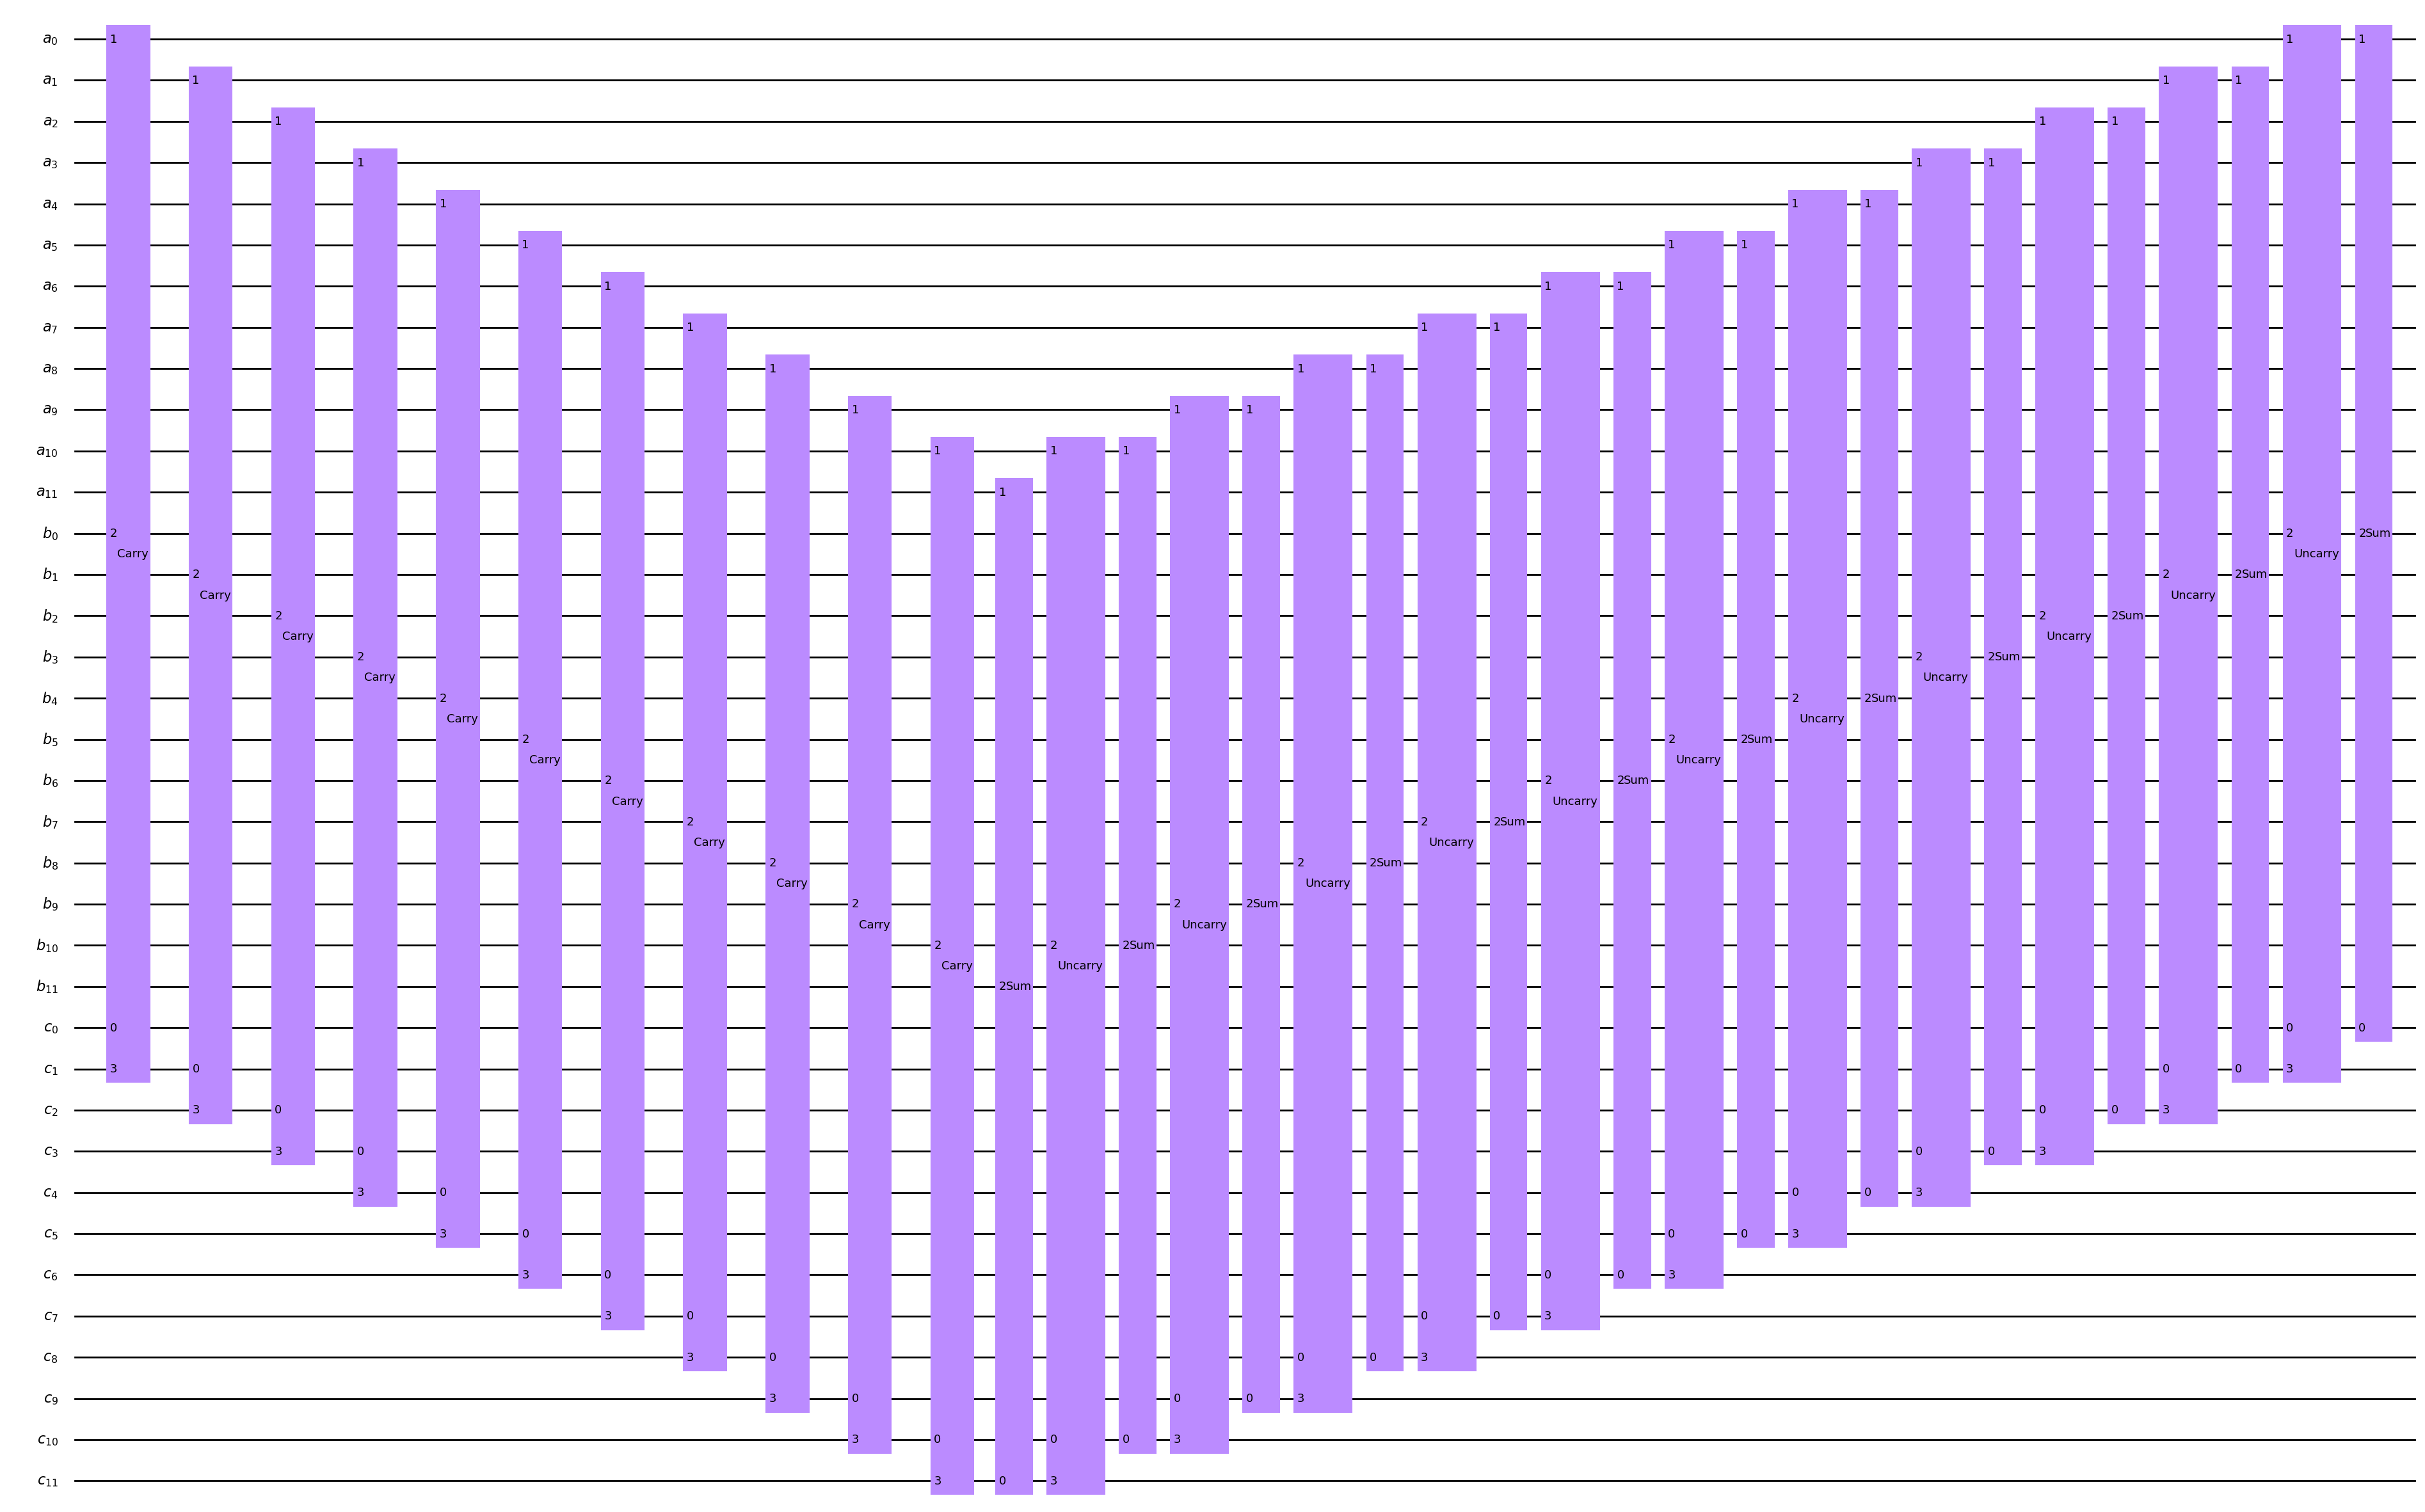

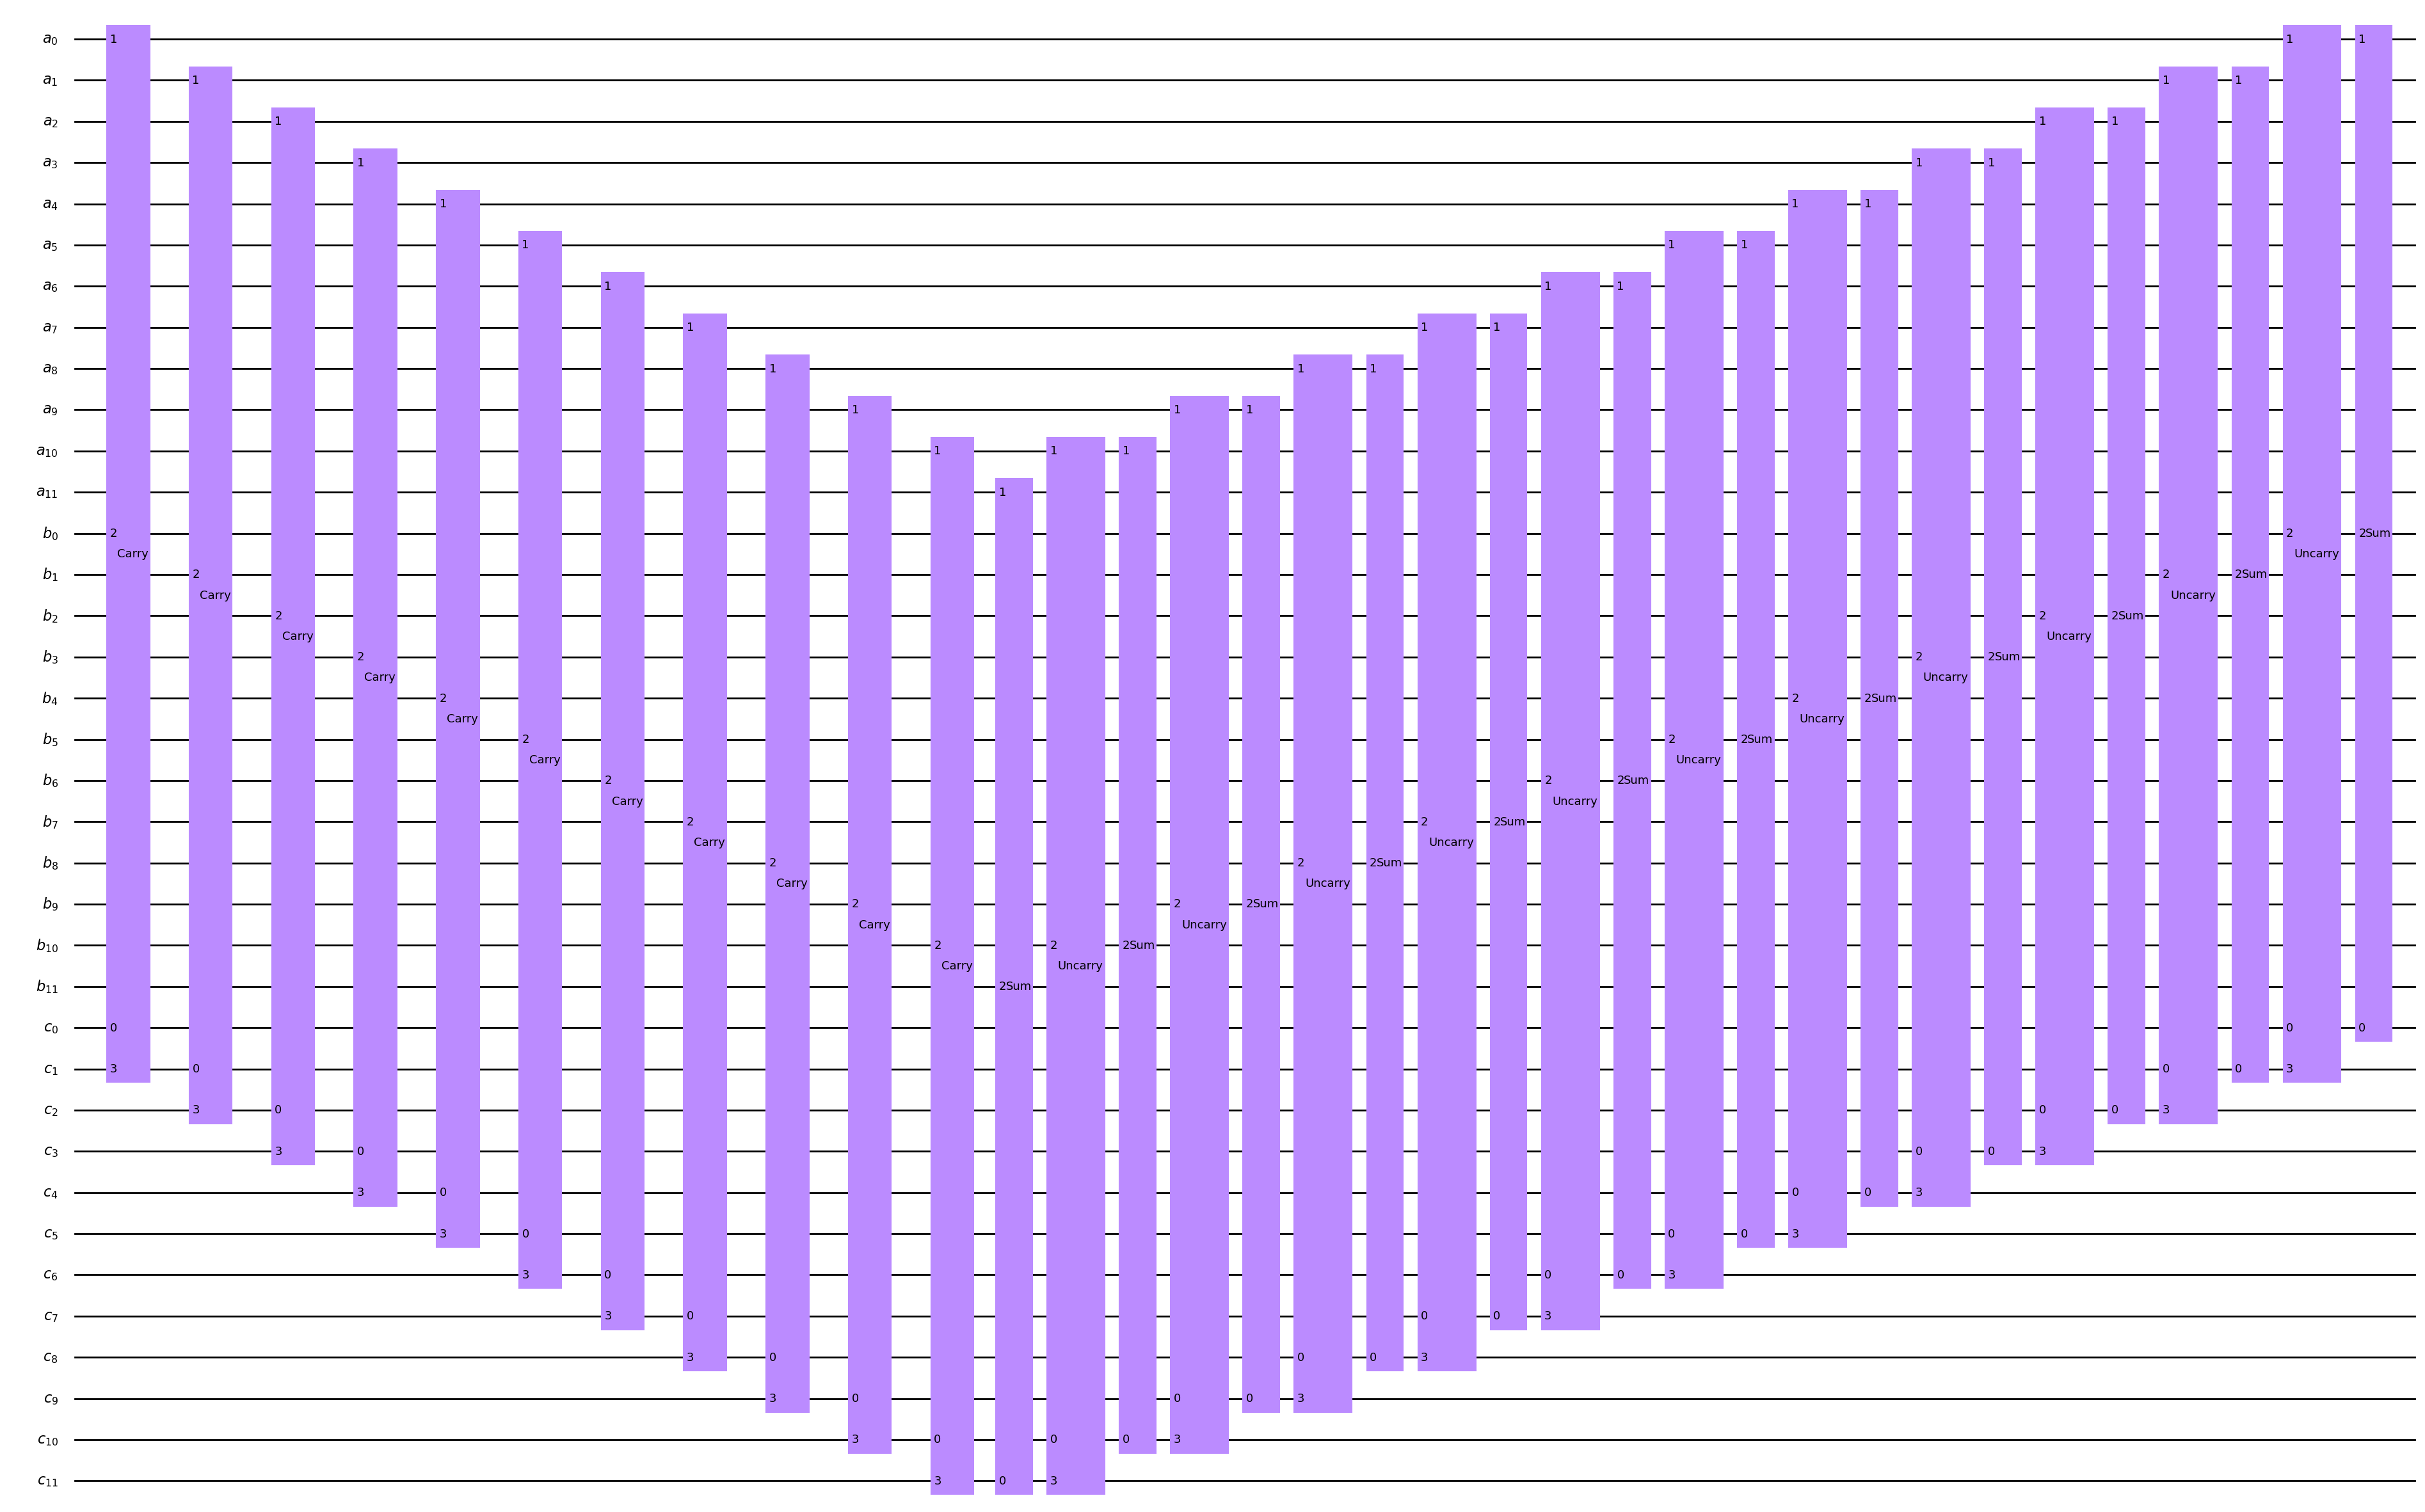

In [40]:
nb_gates_qi.draw(output='mpl', filename='AdderQiskitCirc.png', fold=100)

In [41]:
nb_qb_mi = circuit1.num_qubits
nb_gates_mi = circuit1

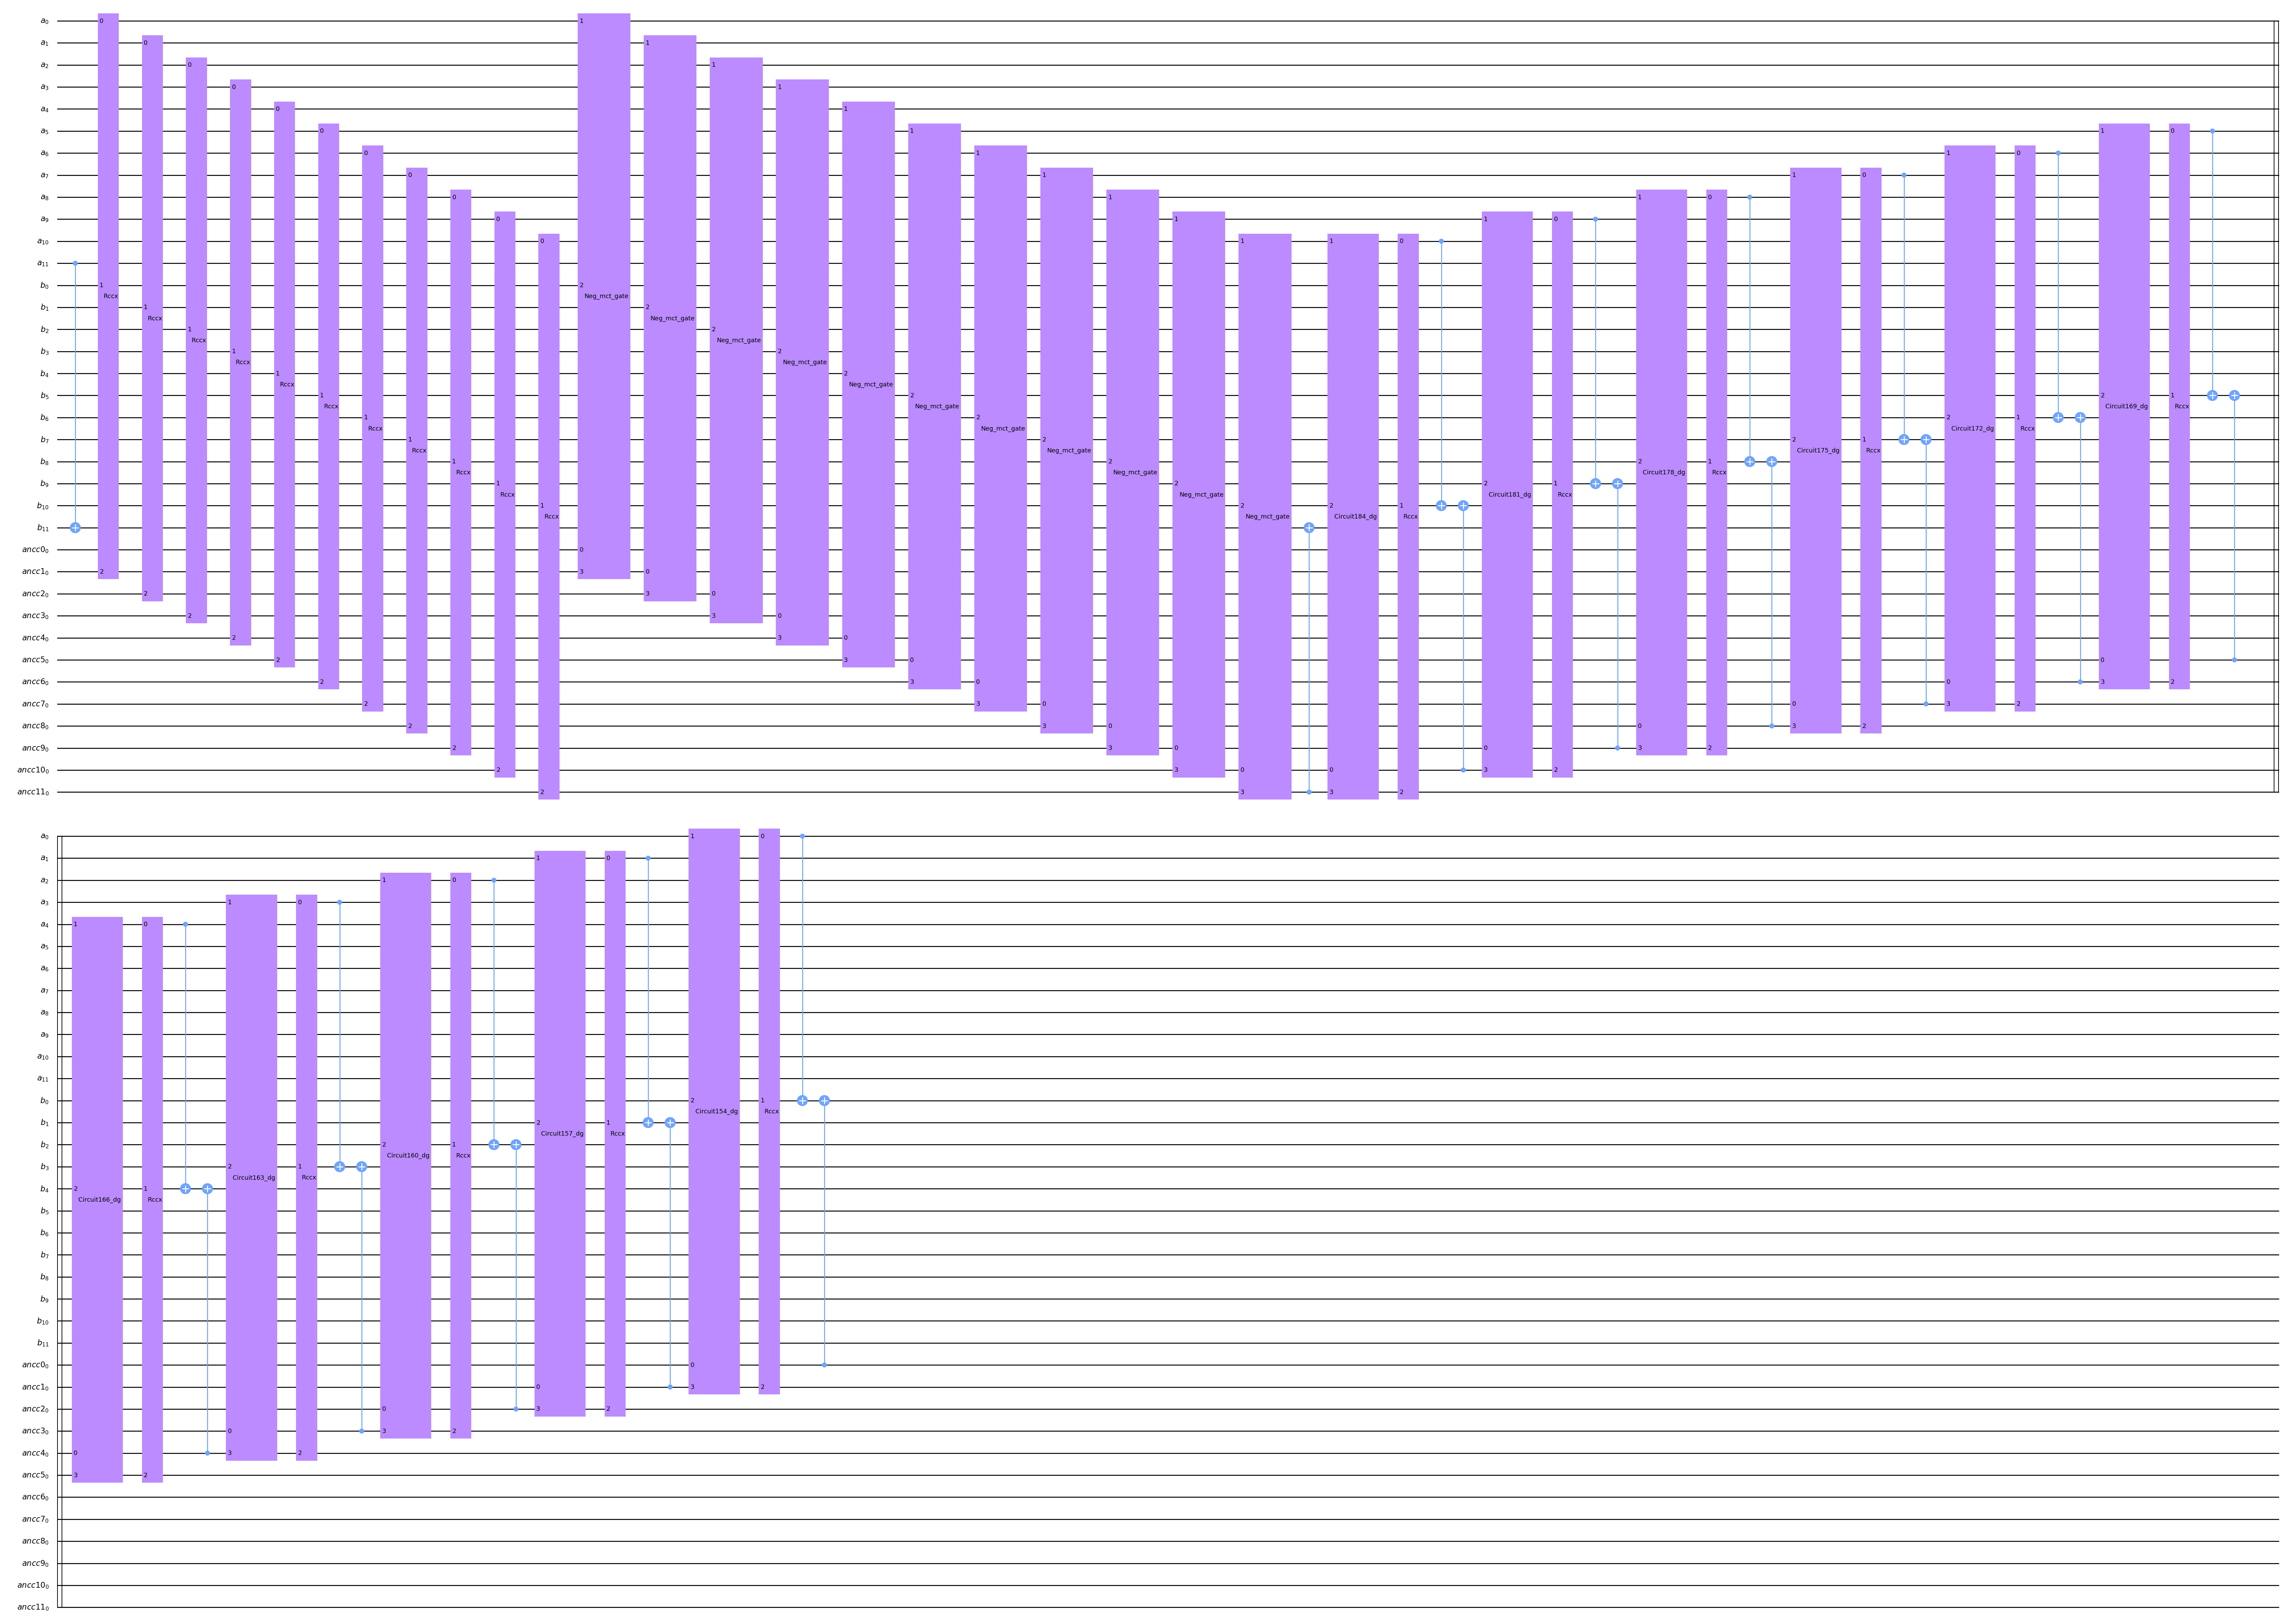

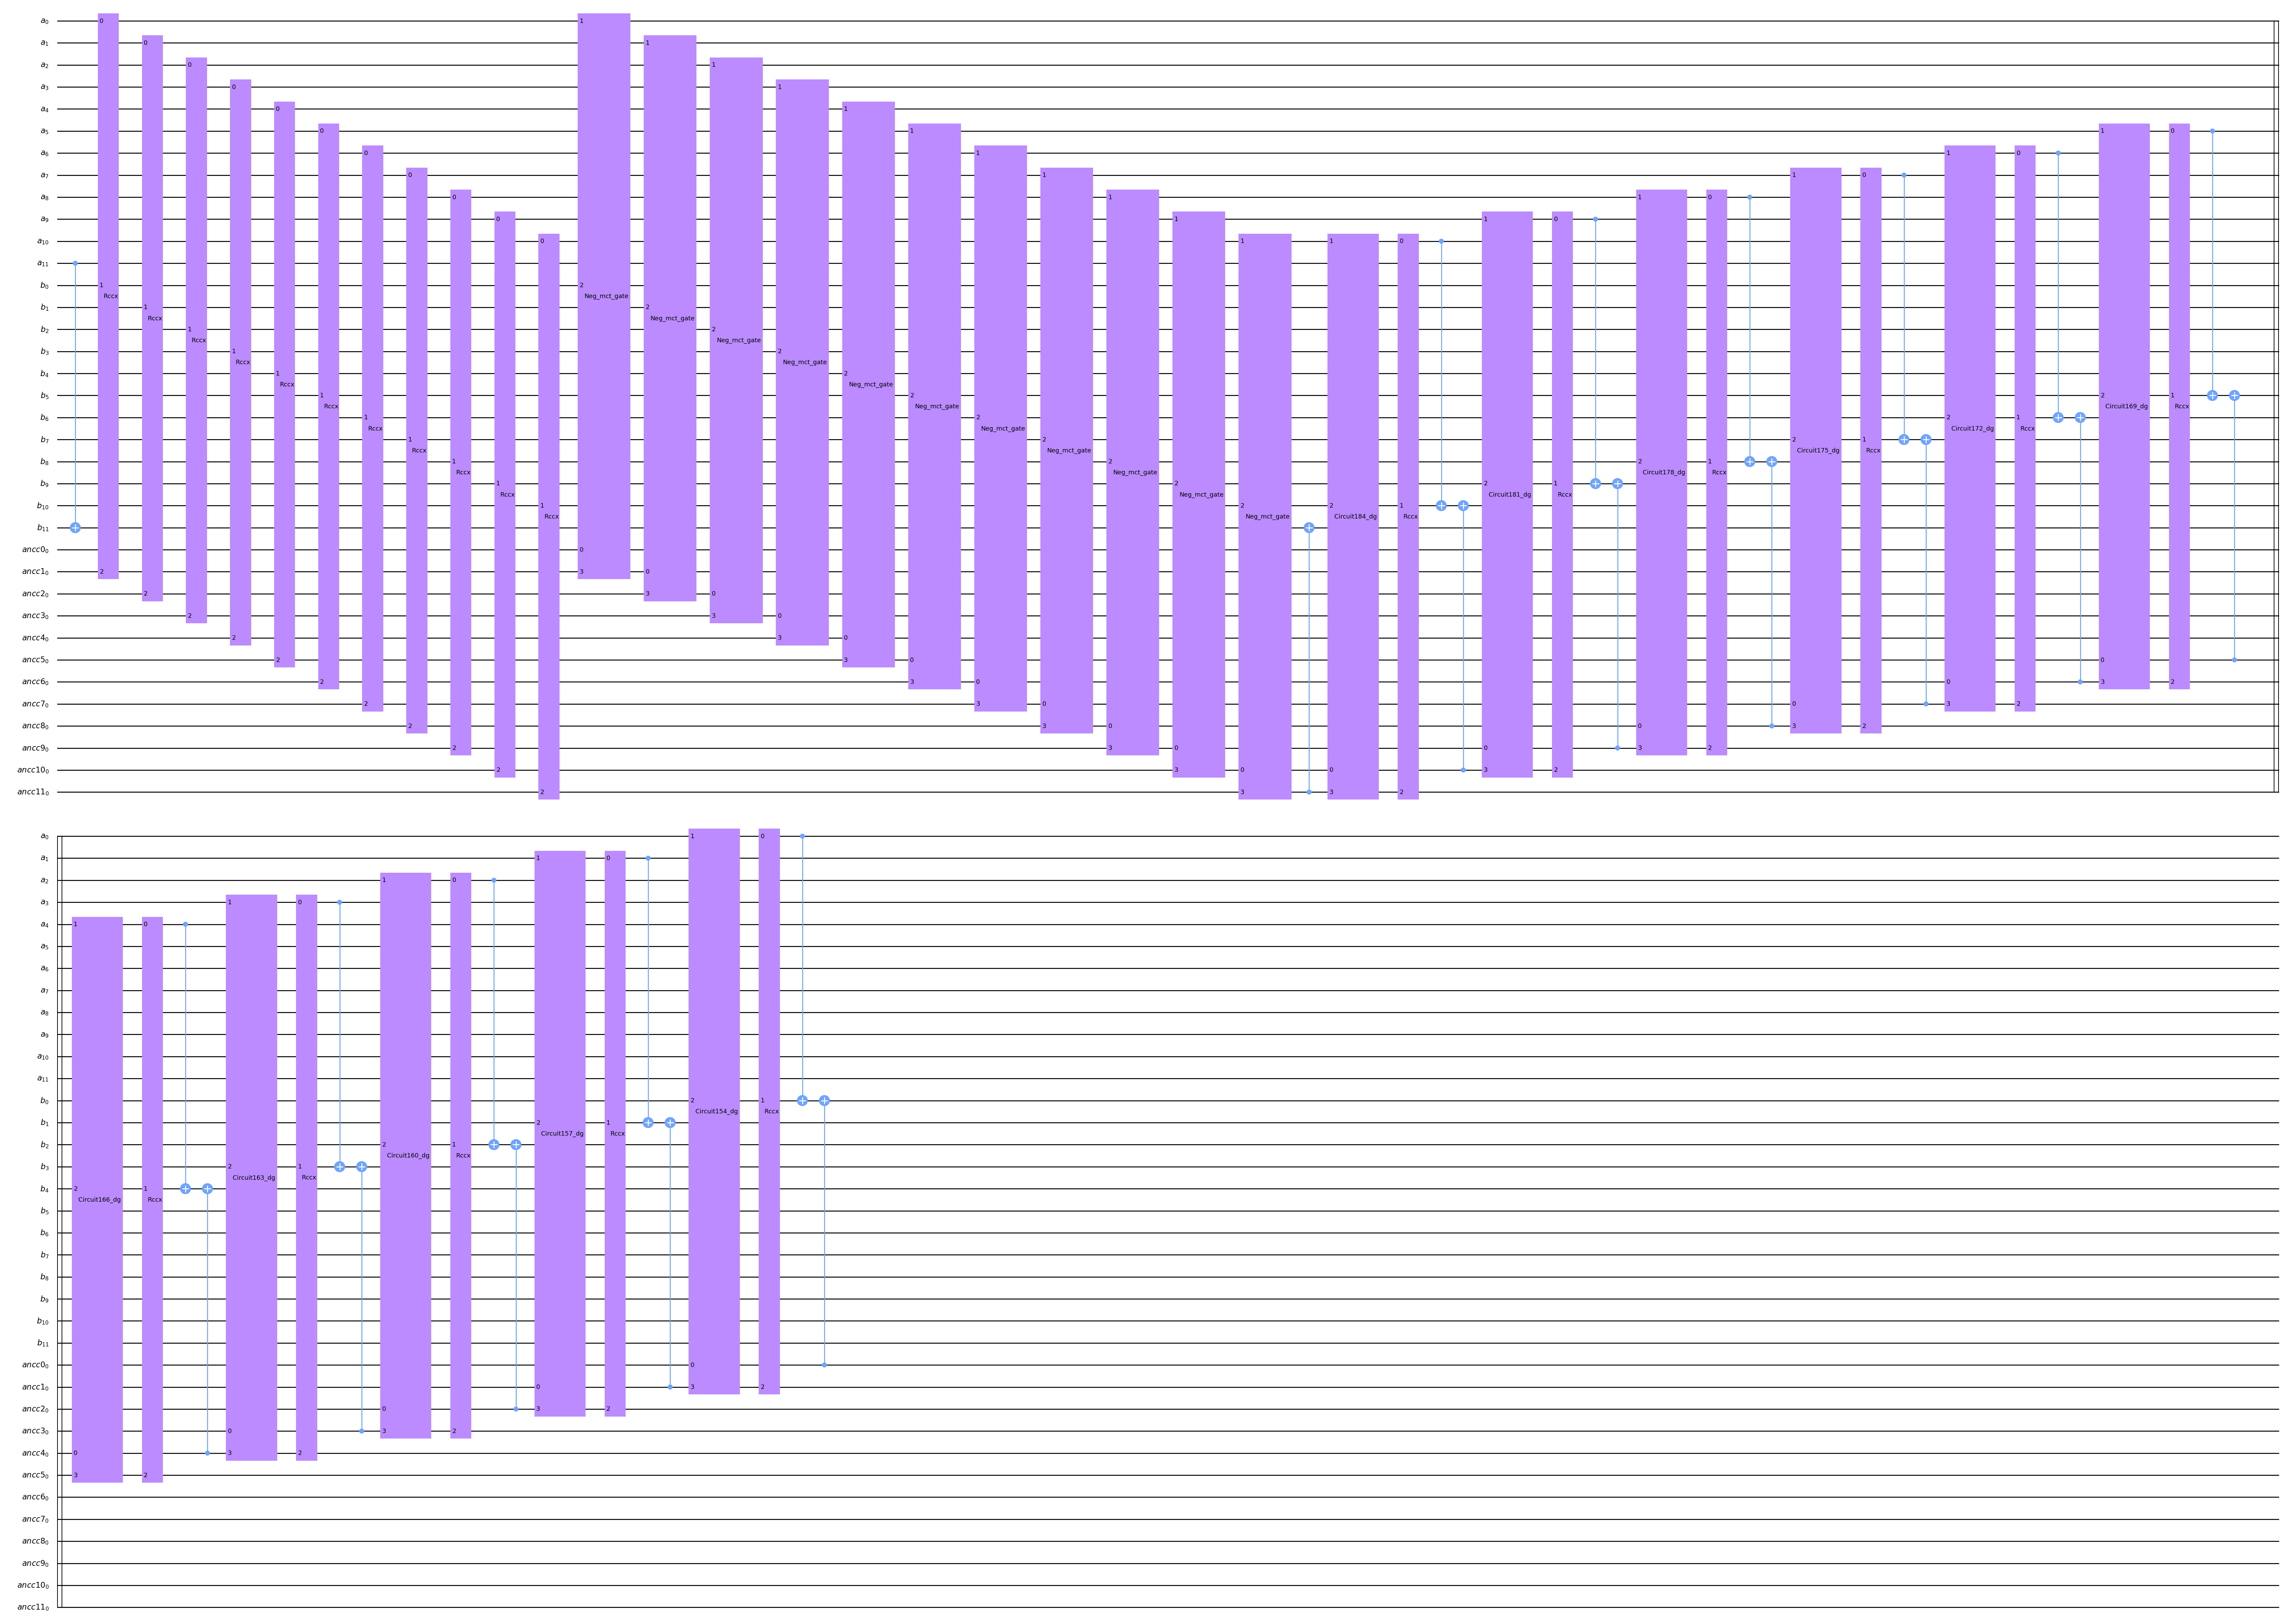

In [42]:
nb_gates_mi.draw(output='mpl', filename='AdderQiskit_PPCirc.png', fold=100)